# Projeto Redes Neurais

**Autor:** Celso Daniel

## Preparação dos Dados

### Importando Bibliotecas

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve
)

### Carregando os Dados para um DataFrame

In [51]:
df = pd.read_csv("data/pima.csv", sep=";")

In [52]:
print(f"Total de linhas: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")

Total de linhas: 768
Total de colunas: 9


In [53]:
display(df.head(5))

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable (0 or 1)
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [54]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Number of times pregnant                                                  768 non-null    int64  
 1   Plasma glucose concentration a 2 hours in an oral glucose tolerance test  768 non-null    int64  
 2   Diastolic blood pressure (mm Hg)                                          768 non-null    int64  
 3   Triceps skin fold thickness (mm)                                          768 non-null    int64  
 4   2-Hour serum insulin (mu U/ml)                                            768 non-null    int64  
 5   Body mass index (weight in kg/(height in m)^2)                            768 non-null    float64
 6   Diabetes pedigree function                                                768 

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable (0 or 1)
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [55]:
cols = {
    "Number of times pregnant": "pregnancies",
    "Plasma glucose concentration a 2 hours in an oral glucose tolerance test": "glucose",
    "Diastolic blood pressure (mm Hg)": "blood_pressure",
    "Triceps skin fold thickness (mm)": "skin_thickness",
    "2-Hour serum insulin (mu U/ml)": "insulin",
    "Body mass index (weight in kg/(height in m)^2)": "bmi",
    "Diabetes pedigree function": "pedigree_function",
    "Age (years)": "age",
    "Class variable (0 or 1)": "diabetes",
}

df = df.rename(columns=cols)

## Análise Exploratória

## Modelagem Preditiva

In [56]:
def run_MLP(df, param_grid=None, name="Experimento", cv_splits=5):
    print("=" * 70)
    print(f"EXECUTANDO: {name.upper()}")
    print("=" * 70)

    X = df.drop(columns=["diabetes"])
    y = df["diabetes"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    if param_grid is None:
        mlp = MLPClassifier(max_iter=500, random_state=42)
        mlp.fit(X_train, y_train)
        best_model = mlp

        print("Rodando MLP com parâmetros padrão (sem GridSearch)...\n")

    else:
        print("Hiperparâmetros Buscados:")
        for key, value in param_grid.items():
            print(f" - {key}: {value}")

        cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
        mlp = MLPClassifier(random_state=42)

        grid_search = GridSearchCV(
            estimator=mlp,
            param_grid=param_grid,
            cv=cv_strategy,
            scoring="roc_auc",
            return_train_score=True,
            n_jobs=-1,
            verbose=0
        )
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        best_idx = grid_search.best_index_

        print("\nMelhores Hiperparâmetros:")
        for key, value in grid_search.best_params_.items():
            print(f" - {key}: {value}")

        print("\nMétricas de Validação Cruzada (Média do CV):")
        print(f" - Train ROC-AUC (CV): {grid_search.cv_results_['mean_train_score'][best_idx]:.4f}")
        print(f" - Val ROC-AUC (CV):   {grid_search.cv_results_['mean_test_score'][best_idx]:.4f}\n")

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    thresholds = np.linspace(0.01, 0.99, 100)
    f1_scores = [f1_score(y_test, (y_proba >= thresh).astype(int), zero_division=0) for thresh in thresholds]

    best_threshold = thresholds[np.argmax(f1_scores)]
    best_f1 = np.max(f1_scores)

    print(f"Threshold Padrão (0.50) -> F1-Score: {f1_score(y_test, (y_proba >= 0.5).astype(int)):.4f}")
    print(f"Threshold Otimizado ({best_threshold:.2f}) -> F1-Score: {best_f1:.4f}\n")

    y_pred_opt = (y_proba >= best_threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred_opt)
    precision = precision_score(y_test, y_pred_opt, zero_division=0)
    recall = recall_score(y_test, y_pred_opt, zero_division=0)
    f1 = f1_score(y_test, y_pred_opt, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    print("Métricas no Conjunto de Teste:")
    print(f" - Accuracy:  {accuracy:.4f}")
    print(f" - Precision:  {precision:.4f}")
    print(f" - Recall: {recall:.4f}")
    print(f" - F1-Score:  {f1:.4f}")
    print(f" - ROC-AUC:   {roc_auc:.4f}\n")

    print("Relatório de Classificação (Teste):")
    print(classification_report(y_test, y_pred_opt, target_names=["Saudável (0)", "Diabético (1)"]))

    conf_matrix = confusion_matrix(y_test, y_pred_opt)

    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["Saudável", "Diabético"], 
                yticklabels=["Saudável", "Diabético"])
    plt.title(f"Matriz de Confusão - {name}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    return best_model, {"Acurácia": accuracy, "ROC-AUC": roc_auc, "F1-Score": f1}

### Modelo na Base 0 (Baseline)

EXECUTANDO: BASELINE
Rodando MLP com parâmetros padrão (sem GridSearch)...

Threshold Padrão (0.50) -> F1-Score: 0.5455
Threshold Otimizado (0.43) -> F1-Score: 0.6222

Métricas no Conjunto de Teste:
 - Accuracy:  0.6688
 - Precision:  0.5185
 - Recall: 0.7778
 - F1-Score:  0.6222
 - ROC-AUC:   0.7013

Relatório de Classificação (Teste):
               precision    recall  f1-score   support

 Saudável (0)       0.84      0.61      0.71       100
Diabético (1)       0.52      0.78      0.62        54

     accuracy                           0.67       154
    macro avg       0.68      0.69      0.66       154
 weighted avg       0.72      0.67      0.68       154



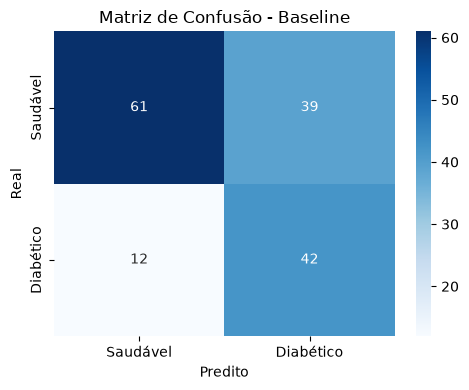

(MLPClassifier(max_iter=500, random_state=42),
 {'Acurácia': 0.6688311688311688,
  'ROC-AUC': 0.7012962962962963,
  'F1-Score': 0.6222222222222222})

In [57]:
run_MLP(df, name="Baseline")

In [58]:
df["diabetes"].value_counts() / len(df)

diabetes
0    0.651042
1    0.348958
Name: count, dtype: float64